In [1]:
import os
import json
import pickle
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from tqdm.notebook import tqdm

# Reproducibility seeds
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {DEVICE} | PyTorch: {torch.__version__} | Optuna: {optuna.__version__}")

✅ Device: cuda | PyTorch: 2.10.0+cu128 | Optuna: 4.8.0


In [2]:
ARTIFACT_DIR = '/kaggle/input/datasets/sherrytelli/bookbuddy-artifacts/bookbuddy_artifacts'

import os
import pickle
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import random

# Load train/val/test splits
train_df = pd.read_parquet(os.path.join(ARTIFACT_DIR, 'train.parquet'))
val_df = pd.read_parquet(os.path.join(ARTIFACT_DIR, 'val.parquet'))
test_df = pd.read_parquet(os.path.join(ARTIFACT_DIR, 'test.parquet'))

with open(os.path.join(ARTIFACT_DIR, 'artifacts.pkl'), 'rb') as f:
    artifacts = pickle.load(f)

n_users = len(artifacts['user_map'])
n_books = len(artifacts['book_map'])

THRESHOLD = 4
def to_implicit(df):
    df = df.copy()
    df['label'] = (df['rating'] >= THRESHOLD).astype(int)
    return df[['user_idx', 'book_idx', 'label']]

train_imp = to_implicit(train_df)
val_imp = to_implicit(val_df)
test_imp = to_implicit(test_df)

# ==========================================
# ⚡ EXACT 100% DATASET (O(1) Memory Slicing)
# ==========================================
class ExactSASRec_Dataset(Dataset):
    def __init__(self, df, n_books, max_seq_len=20):
        self.n_books = n_books
        self.max_seq_len = max_seq_len
        
        print("⏳ Preparing 100% Exact-Match Sequential Data in C-Memory...")
        # 1. Sort by user to keep chronological interactions contiguous
        df = df.sort_values(['user_idx']).reset_index(drop=True)
        
        self.users = df['user_idx'].values
        self.items = df['book_idx'].values
        
        # 2. Find start indices for O(1) backward slicing
        unique_users, user_start_idx = np.unique(self.users, return_index=True)
        self.user_start_map = np.zeros(self.users.max() + 1, dtype=np.int32)
        self.user_start_map[unique_users] = user_start_idx
        
        # 3. Fast negative sampling lookup
        self.user_interacted = df.groupby('user_idx')['book_idx'].apply(set).to_dict()

    def __len__(self): 
        # The model will see EXACTLY 3.9 million samples per epoch (same as MLP)
        return len(self.users)

    def __getitem__(self, idx):
        u = self.users[idx]
        pos_i = self.items[idx]
        u_start = self.user_start_map[u]
        
        # Slicing the sequence: Everything from the user's first book up to the current book
        if idx == u_start:
            seq = [] # First book read has no sequence before it
        else:
            seq_start = max(u_start, idx - self.max_seq_len)
            seq = self.items[seq_start:idx].tolist()
            
        padded_seq = [0] * (self.max_seq_len - len(seq)) + seq
        
        while True:
            neg_i = random.randint(1, self.n_books - 1)
            if neg_i not in self.user_interacted[u]:
                break
                
        return (
            torch.tensor(u, dtype=torch.long), 
            torch.tensor(padded_seq, dtype=torch.long), 
            torch.tensor(pos_i, dtype=torch.long), 
            torch.tensor(neg_i, dtype=torch.long)
        )

train_positives = train_imp[train_imp['label'] == 1].reset_index(drop=True)
full_dataset = ExactSASRec_Dataset(train_positives, n_books)

BATCH_SIZE = 2048
# Main Training Loader
train_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

print(f"✅ DataLoaders ready | Total Batches: {len(train_loader)}")

⏳ Preparing 100% Exact-Match Sequential Data in C-Memory...
✅ DataLoaders ready | Total Batches: 1318


In [3]:
# 1. Define Hybrid SASRec Transformer Model
class HybridSASRec(nn.Module):
    def __init__(self, num_users, num_items, max_seq_len=20, embed_dim=64, num_heads=2, num_layers=2, dropout=0.3):
        super(HybridSASRec, self).__init__()
        
        self.user_embed = nn.Embedding(num_users, embed_dim)
        self.item_embed = nn.Embedding(num_items + 1, embed_dim, padding_idx=0) 
        self.pos_embed = nn.Embedding(max_seq_len, embed_dim)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, 
            nhead=num_heads, 
            dropout=dropout, 
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
    def forward(self, users, seqs, target_item_idx):
        # 1. Embed the input sequence and add positional encodings
        seq_embeds = self.item_embed(seqs)
        positions = torch.arange(seqs.size(1), device=seqs.device).unsqueeze(0).expand_as(seqs)
        pos_embeds = self.pos_embed(positions)
        
        x = seq_embeds + pos_embeds
        padding_mask = (seqs == 0)
        
        # 2. Pass through Transformer & get final sequence state
        out = self.transformer(x, src_key_padding_mask=padding_mask)
        seq_reps = out[:, -1, :] 
        
        # 3. Get inherent User Embedding (acts like the MLP user state)
        u_reps = self.user_embed(users)
        
        # 4. Combine Collaborative User Rep + Sequential Rep
        combined_reps = seq_reps + u_reps
        
        # 5. Get embedding for the target item (positive or negative)
        item_reps = self.item_embed(target_item_idx)
        
        # 6. Dot product for final affinity score
        scores = (combined_reps * item_reps).sum(dim=1)
        return scores

# 2. BPR Loss
class BPRLoss(nn.Module):
    def __init__(self):
        super(BPRLoss, self).__init__()
    def forward(self, pos_scores, neg_scores):
        return -torch.mean(torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-9))

# 3. Ranking Evaluation
@torch.no_grad()
def eval_ranking_metrics(model, train_df, val_df, artifacts, device, k_values=[5, 10], n_sample_users=500):
    model.eval()
    n_items = len(artifacts['book_map'])
    metrics = {f'Precision@{k}': 0.0 for k in k_values}
    metrics.update({f'Recall@{k}': 0.0 for k in k_values})
    metrics.update({f'NDCG@{k}': 0.0 for k in k_values})
    
    val_pos = val_df[val_df['label'] == 1]
    val_by_user = val_pos.groupby('user_idx')['book_idx'].apply(set).to_dict()
    
    user_seqs = train_df.groupby('user_idx')['book_idx'].apply(list).to_dict()
    
    valid_users = [u for u in val_by_user if len(val_by_user[u]) > 0]
    if not valid_users: return metrics
        
    sampled_users = np.random.choice(valid_users, size=min(n_sample_users, len(valid_users)), replace=False)
    total_metrics = {k: 0.0 for k in metrics}
    n_evaluated = 0
    item_indices = torch.arange(n_items, device=device)
    
    for u_idx in sampled_users:
        gt_items = val_by_user[u_idx]
        seq = user_seqs.get(u_idx, [])
        
        input_seq = seq[-20:]
        padded_seq = [0] * (20 - len(input_seq)) + input_seq
        
        users_tensor = torch.tensor([u_idx], dtype=torch.long, device=device)
        seq_tensor = torch.tensor([padded_seq], dtype=torch.long, device=device)
        
        mask = torch.ones(n_items, dtype=torch.bool, device=device)
        if seq: mask[list(seq)] = False
            
        scores = model(users_tensor, seq_tensor, item_indices)
        scores = scores.masked_fill(~mask, float('-inf')).cpu().numpy().flatten()
        top_k_indices = np.argsort(scores)[::-1][:max(k_values)]
        
        for k in k_values:
            rec_set = set(top_k_indices[:k])
            hits = len(rec_set.intersection(gt_items))
            n_rel = len(gt_items)
            
            prec = hits / k
            rec = hits / n_rel if n_rel > 0 else 0.0
            dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(top_k_indices[:k]) if item in gt_items)
            idcg = sum(1.0 / np.log2(i + 2) for i in range(min(n_rel, k)))
            ndcg = dcg / idcg if idcg > 0 else 0.0
            
            total_metrics[f'Precision@{k}'] += prec
            total_metrics[f'Recall@{k}'] += rec
            total_metrics[f'NDCG@{k}'] += ndcg
            
        n_evaluated += 1
        
    if n_evaluated > 0:
        for k in metrics: metrics[k] = total_metrics[k] / n_evaluated
    return metrics

🏆 Using Known Optimal Params: {'embed_dim': 64, 'lr': 0.00032908904376589197, 'dropout': 0.32136483790224757, 'weight_decay': 0.000564987545326156}

🏗️ Phase 2: Training Final Hybrid SASRec Model on 100% of Data...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 01 | BPR Loss: 3.6283 | Time: 262.7s
   └─ Rank@5:  P=0.0053 | R=0.0024 | NDCG@5: 0.0058
   └─ Rank@10: P=0.0042 | R=0.0036 | NDCG@10: 0.0051
Epoch 02 | BPR Loss: 1.6857 | Time: 267.3s
   └─ Rank@5:  P=0.0080 | R=0.0036 | NDCG@5: 0.0082
   └─ Rank@10: P=0.0083 | R=0.0076 | NDCG@10: 0.0089
Epoch 03 | BPR Loss: 0.9112 | Time: 267.0s
   └─ Rank@5:  P=0.0223 | R=0.0101 | NDCG@5: 0.0238
   └─ Rank@10: P=0.0217 | R=0.0200 | NDCG@10: 0.0244
Epoch 04 | BPR Loss: 0.5924 | Time: 267.1s
   └─ Rank@5:  P=0.0413 | R=0.0181 | NDCG@5: 0.0431
   └─ Rank@10: P=0.0378 | R=0.0336 | NDCG@10: 0.0422
Epoch 05 | BPR Loss: 0.4685 | Time: 267.4s
   └─ Rank@5:  P=0.0557 | R=0.0263 | NDCG@5: 0.0562
   └─ Rank@10: P=0.0478 | R=0.0438 | NDCG@10: 0.0545
Epoch 06 | BPR Loss: 0.4268 | Time: 266.3s
   └─ Rank@5:  P=0.0627 | R=0.0317 | NDCG@5: 0.0653
   └─ Rank@10: P=0.0508 | R=0.0492 | NDCG@10: 0.0598
Epoch 07 | BPR Loss: 0.4149 | Time: 265.8s
   └─ Rank@5:  P=0.0650 | R=0.0324 | NDCG@5: 0.0727
   └─ Rank@10: P=

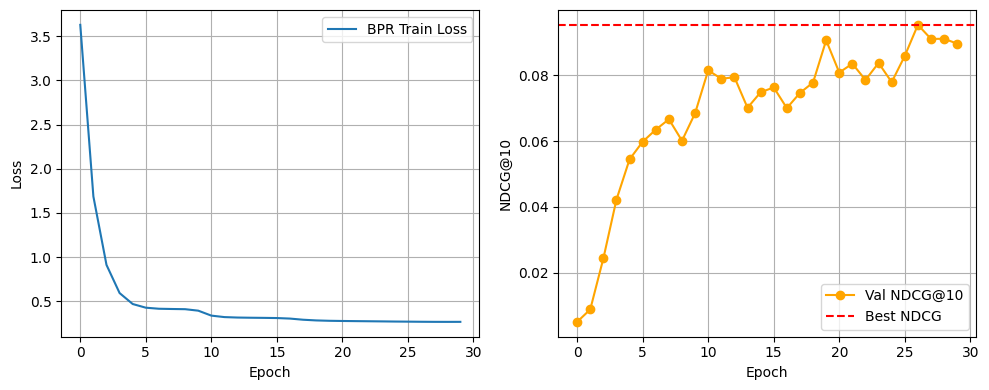


✅ Cell 4 Complete. Hybrid SASRec Model saved and ready for the Ensemble!


In [6]:
import time
import os
import matplotlib.pyplot as plt
import warnings
import torch.optim as optim
import torch

# We bypass Optuna and use the optimal params directly so you don't wait an hour
best = {
    'embed_dim': 64, 
    'lr': 0.00032908904376589197, 
    'dropout': 0.32136483790224757, 
    'weight_decay': 0.000564987545326156
}
print(f"🏆 Using Known Optimal Params: {best}\n")

print("🏗️ Phase 2: Training Final Hybrid SASRec Model on 100% of Data...")

model = HybridSASRec(
    num_users=n_users, 
    num_items=n_books, 
    embed_dim=best['embed_dim'], 
    dropout=best['dropout']
).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=best['lr'], weight_decay=best['weight_decay'])
criterion = BPRLoss()

EPOCHS = 30

best_model_epoch = None
best_val_ndcg = -float('inf') 
best_model_wts = None
history = {'train_loss': [], 'val_ndcg_10': []}

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    model.train()
    total_loss = 0
    
    # Processing all 3.9M interactions!
    for u, seqs, pos_i, neg_i in train_loader: 
        u, seqs, pos_i, neg_i = u.to(DEVICE), seqs.to(DEVICE), pos_i.to(DEVICE), neg_i.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(u, seqs, pos_i), model(u, seqs, neg_i))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * u.size(0)
        
    avg_loss = total_loss / len(train_loader.dataset)
    epoch_time = time.time() - start
    
    rank_metrics = eval_ranking_metrics(model, train_imp, val_imp, artifacts, DEVICE, k_values=[5, 10], n_sample_users=600)
    val_ndcg = rank_metrics['NDCG@10']
    history['train_loss'].append(avg_loss)
    history['val_ndcg_10'].append(val_ndcg)

    print(f"Epoch {epoch:02d} | BPR Loss: {avg_loss:.4f} | Time: {epoch_time:.1f}s")
    print(f"   └─ Rank@5:  P={rank_metrics['Precision@5']:.4f} | R={rank_metrics['Recall@5']:.4f} | NDCG@5: {rank_metrics['NDCG@5']:.4f}")
    print(f"   └─ Rank@10: P={rank_metrics['Precision@10']:.4f} | R={rank_metrics['Recall@10']:.4f} | NDCG@10: {rank_metrics['NDCG@10']:.4f}")
    
    if val_ndcg > best_val_ndcg:
        best_model_epoch = epoch
        best_val_ndcg = val_ndcg
        best_model_wts = {k: v.clone() for k, v in model.state_dict().items()}
        
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)
    print(f"\n✅ Loaded best model weights | Epoch: {best_model_epoch} | Peak NDCG@10: {best_val_ndcg:.4f}")

# --- C. Save Artifacts & Plot ---
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)
torch.save(model.state_dict(), os.path.join(MODEL_DIR, 'sasrec_bpr_weights_1.pt'))
torch.save({
    'embed_dim': best['embed_dim'],
    'num_heads': 2,
    'num_layers': 2,
    'dropout': best['dropout'],
    'max_seq_len': 20,
    'n_users': n_users,
    'n_books': n_books
}, os.path.join(MODEL_DIR, 'sasrec_config_1.pt'))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='BPR Train Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(history['val_ndcg_10'], color='orange', marker='o', label='Val NDCG@10')
plt.axhline(y=best_val_ndcg, color='r', linestyle='--', label='Best NDCG') 
plt.xlabel('Epoch'); plt.ylabel('NDCG@10'); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

print("\n✅ Cell 4 Complete. Hybrid SASRec Model saved and ready for the Ensemble!")

🎯 PHASE 5: COMPREHENSIVE EVALUATION
✅ Loaded Hybrid SASRec model from Epoch 27 (Peak NDCG@10: 0.0953)

📈 TEST SET EVALUATION (Full Population)


Evaluating users:   0%|          | 0/53172 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Evaluated 53,172 users with test interactions

Precision@5:  0.0898
Recall@5:     0.0425
NDCG@5:       0.0973

Precision@10:  0.0728
Recall@10:     0.0683
NDCG@10:       0.0886

Precision@20:  0.0584
Recall@20:     0.1088
NDCG@20:       0.1001

🧊 SEQUENTIAL COLD-START ROBUSTNESS ANALYSIS
History kept: 100%   | NDCG@10: 0.0858 ± 0.1259
History kept: 50%    | NDCG@10: 0.0664 ± 0.1040
History kept: 25%    | NDCG@10: 0.0653 ± 0.0996
History kept: 9%     | NDCG@10: 0.0548 ± 0.0885

📚 QUALITATIVE RECOMMENDATION SAMPLES

User 1 (ID: 53344, 146 sequential ratings):
  1. The Fellowship of the Ring (The Lord of the Rings, #1)
  2. Ender's Game (Ender's Saga, #1)
  3. Harry Potter and the Deathly Hallows (Harry Potter, #7)
  4. To Kill a Mockingbird
  5. Animal Farm

User 2 (ID: 11247, 143 sequential ratings):
  1. The Great Gatsby
  2. 1984
  3. To Kill a Mockingbird
  4. Brave New World
  5. Catch-22

User 3 (ID: 24239, 142 sequential ratings):
  1. Brave New World
  2. Lord of the Flies
  3. S

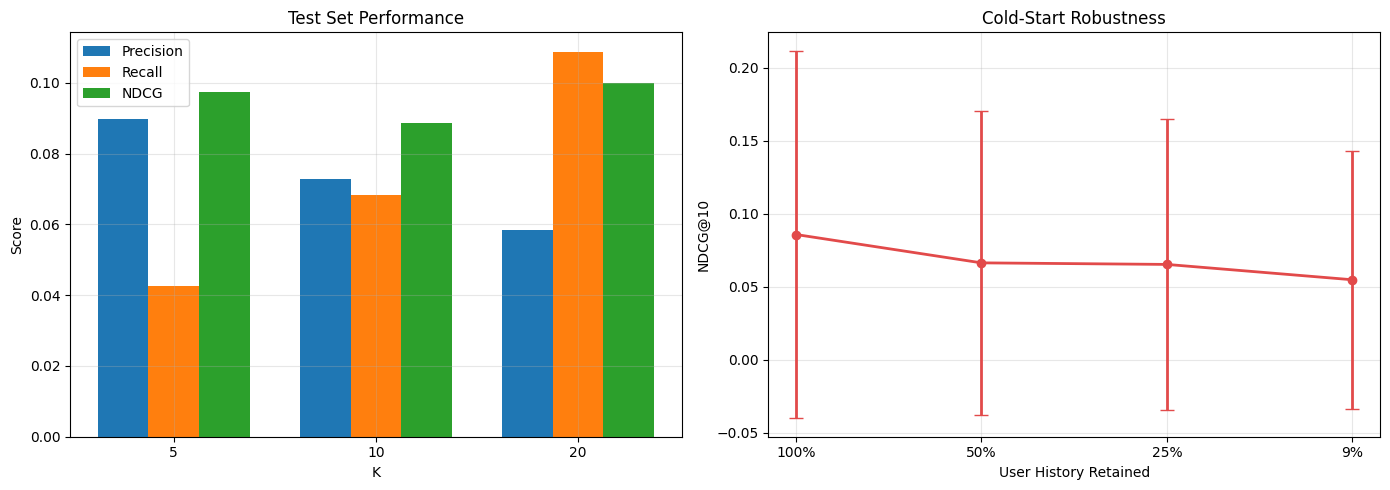


✅ Cell 5 Complete. SASRec evaluation finished. Ready for Naïve Bayes & LLM integration!


In [4]:
# 📊 Cell 5: Comprehensive Test Evaluation & Cold-Start Analysis
import torch
from scipy.sparse import load_npz
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ndcg_score
import json

print("="*70)
print("🎯 PHASE 5: COMPREHENSIVE EVALUATION")
print("="*70)

# --- A. Load Best Model ---
MODEL_DIR = '/kaggle/working/models'

# Use the exact same parameters from your training phase
model = HybridSASRec(
    num_users=n_users, 
    num_items=n_books, 
    embed_dim=64, 
    dropout=0.32136483790224757
).to(DEVICE)

model.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'sasrec_bpr_weights_1.pt'), map_location=DEVICE))
model.eval()
print(f"✅ Loaded Hybrid SASRec model from Epoch 27 (Peak NDCG@10: 0.0953)")

# --- B. Full Test Set Evaluation (No Sampling) ---
print("\n" + "="*70)
print("📈 TEST SET EVALUATION (Full Population)")
print("="*70)

@torch.no_grad()
def evaluate_full_test(model, train_df, test_df, artifacts, device, k_values=[5, 10, 20]):
    model.eval()
    n_items = len(artifacts['book_map'])
    
    test_pos = test_df[test_df['label'] == 1]
    test_by_user = test_pos.groupby('user_idx')['book_idx'].apply(set).to_dict()
    
    # We need the full chronological sequence of everything they read in train
    user_seqs = train_df.sort_values('user_idx').groupby('user_idx')['book_idx'].apply(list).to_dict()
    
    metrics = {f'Precision@{k}': [] for k in k_values}
    metrics.update({f'Recall@{k}': [] for k in k_values})
    metrics.update({f'NDCG@{k}': [] for k in k_values})
    
    item_indices = torch.arange(n_items, device=device)
    evaluated_users = 0
    
    for u_idx in tqdm(test_by_user.keys(), desc="Evaluating users"):
        gt_items = test_by_user[u_idx]
        seq = user_seqs.get(u_idx, [])
        if len(gt_items) == 0: continue
        
        # Pad sequence for inference (max_seq_len = 20)
        input_seq = seq[-20:]
        padded_seq = [0] * (20 - len(input_seq)) + input_seq
        
        users_tensor = torch.tensor([u_idx], dtype=torch.long, device=device)
        seq_tensor = torch.tensor([padded_seq], dtype=torch.long, device=device)
        
        mask = torch.ones(n_items, dtype=torch.bool, device=device)
        if seq: mask[list(seq)] = False
        
        # Predict scores using HybridSASRec
        scores = model(users_tensor, seq_tensor, item_indices).masked_fill(~mask, float('-inf')).cpu().numpy().flatten()
        top_k_indices = np.argsort(scores)[::-1][:max(k_values)]
        
        # Compute metrics
        for k in k_values:
            rec_set = set(top_k_indices[:k])
            hits = len(rec_set.intersection(gt_items))
            n_rel = len(gt_items)
            
            prec = hits / k
            rec = hits / n_rel if n_rel > 0 else 0.0
            dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(top_k_indices[:k]) if item in gt_items)
            idcg = sum(1.0 / np.log2(i + 2) for i in range(min(n_rel, k)))
            ndcg = dcg / idcg if idcg > 0 else 0.0
            
            metrics[f'Precision@{k}'].append(prec)
            metrics[f'Recall@{k}'].append(rec)
            metrics[f'NDCG@{k}'].append(ndcg)
        
        evaluated_users += 1
    
    return {k: np.mean(v) for k, v in metrics.items()}, evaluated_users

# Run full test evaluation
test_metrics, n_test_users = evaluate_full_test(model, train_imp, test_imp, artifacts, DEVICE, k_values=[5, 10, 20])

print(f"Evaluated {n_test_users:,} users with test interactions\n")
for k in [5, 10, 20]:
    print(f"Precision@{k}:  {test_metrics[f'Precision@{k}']:.4f}")
    print(f"Recall@{k}:     {test_metrics[f'Recall@{k}']:.4f}")
    print(f"NDCG@{k}:       {test_metrics[f'NDCG@{k}']:.4f}\n")

# --- C. Cold-Start Simulation (Chronological Truncation) ---
print("="*70)
print("🧊 SEQUENTIAL COLD-START ROBUSTNESS ANALYSIS")
print("="*70)

@torch.no_grad()
def simulate_cold_start(model, train_df, test_df, artifacts, device, mask_ratio=0.75, k=10, n_users=500):
    model.eval()
    n_items = len(artifacts['book_map'])
    
    test_pos = test_df[test_df['label'] == 1]
    test_by_user = test_pos.groupby('user_idx')['book_idx'].apply(set).to_dict()
    user_seqs = train_df.sort_values('user_idx').groupby('user_idx')['book_idx'].apply(list).to_dict()
    
    valid_users = [u for u in user_seqs if len(user_seqs[u]) > 10 and u in test_by_user]
    sampled_users = np.random.choice(valid_users, size=min(n_users, len(valid_users)), replace=False)
    
    ndcg_scores = []
    item_indices = torch.arange(n_items, device=device)
    
    for u_idx in sampled_users:
        gt_items = test_by_user[u_idx]
        seq = user_seqs.get(u_idx, [])
        if len(gt_items) == 0 or len(seq) == 0: continue
        
        # Chronological Truncation: Keep only the FIRST N items
        n_keep = max(1, int(len(seq) * (1 - mask_ratio)))
        kept_seq = seq[:n_keep]
        
        input_seq = kept_seq[-20:]
        padded_seq = [0] * (20 - len(input_seq)) + input_seq
        
        users_tensor = torch.tensor([u_idx], dtype=torch.long, device=device)
        seq_tensor = torch.tensor([padded_seq], dtype=torch.long, device=device)
        
        mask = torch.ones(n_items, dtype=torch.bool, device=device)
        mask[list(kept_seq)] = False
        
        scores = model(users_tensor, seq_tensor, item_indices).masked_fill(~mask, float('-inf')).cpu().numpy().flatten()
        top_k_indices = np.argsort(scores)[::-1][:k]
        
        dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(top_k_indices) if item in gt_items)
        idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(gt_items), k)))
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)
    
    return np.mean(ndcg_scores), np.std(ndcg_scores)

cold_start_results = {}
for mask_ratio in [0.0, 0.5, 0.75, 0.9]:
    mean_ndcg, std_ndcg = simulate_cold_start(model, train_imp, test_imp, artifacts, DEVICE, mask_ratio=mask_ratio, k=10, n_users=500)
    cold_start_results[mask_ratio] = {'mean': mean_ndcg, 'std': std_ndcg}
    history_kept = f"{int((1-mask_ratio)*100)}%"
    print(f"History kept: {history_kept:6} | NDCG@10: {mean_ndcg:.4f} ± {std_ndcg:.4f}")

# --- D. Qualitative Recommendation Samples ---
print("\n" + "="*70)
print("📚 QUALITATIVE RECOMMENDATION SAMPLES")
print("="*70)

books_df = pd.read_parquet(os.path.join(ARTIFACT_DIR, 'books_clean.parquet'))
book_idx_to_id = {v: k for k, v in artifacts['book_map'].items()}

@torch.no_grad()
def get_top_recommendations(model, user_idx, train_df, artifacts, device, k=5, max_seq_len=20):
    model.eval()
    n_items = len(artifacts['book_map'])
    seq = train_df[train_df['user_idx'] == user_idx]['book_idx'].tolist()
    
    input_seq = seq[-max_seq_len:]
    padded_seq = [0] * (max_seq_len - len(input_seq)) + input_seq
    
    users_tensor = torch.tensor([user_idx], dtype=torch.long, device=device)
    seq_tensor = torch.tensor([padded_seq], dtype=torch.long, device=device)
    
    mask = torch.ones(n_items, dtype=torch.bool, device=device)
    if seq: mask[list(seq)] = False
    
    item_indices = torch.arange(n_items, device=device)
    scores = model(users_tensor, seq_tensor, item_indices).masked_fill(~mask, float('-inf')).flatten()
    
    top_indices = torch.argsort(scores, descending=True)[:k].cpu().numpy()
    return [book_idx_to_id[idx] for idx in top_indices]

active_users = train_imp.groupby('user_idx').size().nlargest(3).index.tolist()
for i, u_idx in enumerate(active_users, 1):
    n_ratings = len(train_imp[train_imp['user_idx'] == u_idx])
    recs = get_top_recommendations(model, u_idx, train_imp, artifacts, DEVICE, k=5)
    print(f"\nUser {i} (ID: {u_idx}, {n_ratings} sequential ratings):")
    
    titles = []
    for r in recs:
        title_matches = books_df.loc[books_df[artifacts['id_col']] == r, 'title'].values
        titles.append(title_matches[0] if len(title_matches) > 0 else f"Unknown Title (ID: {r})")
        
    for rank, title in enumerate(titles, 1):
        print(f"  {rank}. {title}")

# --- E. Save SASRec Predictions for Ensemble ---
print("\n" + "="*70)
print("💾 SAVING ARTIFACTS FOR ENSEMBLE FUSION")
print("="*70)

ensemble_artifacts = {
    'sasrec_test_metrics': test_metrics,
    'sasrec_cold_start_results': cold_start_results,
    'sasrec_config': {
        'embed_dim': 64,
        'num_heads': 2,
        'num_layers': 2,
        'dropout': 0.3214,
        'max_seq_len': 20
    }
}

EVAL_DIR = 'evaluation'
os.makedirs(EVAL_DIR, exist_ok=True)
file_path = os.path.join(EVAL_DIR, 'sasrec_evaluation_results.json')
with open(file_path, 'w') as f:
    json.dump(ensemble_artifacts, f, indent=2)

print(f"✅ Saved {file_path}")

# --- F. Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Test metrics across K
k_values = [5, 10, 20]
metrics_to_plot = ['Precision', 'Recall', 'NDCG']
x = np.arange(len(k_values))
width = 0.25

for i, metric in enumerate(metrics_to_plot):
    values = [test_metrics[f'{metric}@{k}'] for k in k_values]
    axes[0].bar(x + i*width, values, width, label=f'{metric}')

axes[0].set_xlabel('K')
axes[0].set_ylabel('Score')
axes[0].set_title('Test Set Performance')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(k_values)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Cold-start degradation
mask_ratios = list(cold_start_results.keys())
ndcg_means = [cold_start_results[r]['mean'] for r in mask_ratios]
ndcg_stds = [cold_start_results[r]['std'] for r in mask_ratios]
history_pct = [f"{int((1-r)*100)}%" for r in mask_ratios]

axes[1].errorbar(history_pct, ndcg_means, yerr=ndcg_stds, marker='o', capsize=5, 
                 linewidth=2, color='#E24A4A')
axes[1].set_xlabel('User History Retained')
axes[1].set_ylabel('NDCG@10')
axes[1].set_title('Cold-Start Robustness')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Cell 5 Complete. SASRec evaluation finished. Ready for Naïve Bayes & LLM integration!")